### 🤖 Guía de Asistencia con IA: Estrategias de Limpieza de Datos (Nulos y Outliers)

En esta notebook, utilizaremos la Inteligencia Artificial como copiloto de aprendizaje. Aquí tienes algunas sugerencias de cómo interactuar con un asistente de IA (como Gemini o ChatGPT):

- **Imputación lógica**: Pregúntale a la IA: *'Tengo nulos en la columna 'Ingresos' (15%). ¿Cuándo es conveniente imputar con la mediana vs. con la media o eliminar los registros? Explica pros y contras'*.
- **Manejo de Outliers**: Pregúntale: *'¿Qué métodos existen en Python para identificar outliers de manera analítica (Z-score, IQR) y cómo los implemento en un DataFrame?'*.


# Programa Ingenias+ Data Science

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [51]:
import sklearn

In [52]:
# Chequeamos nuestra version
sklearn.__version__

'1.9.1'

Una vez que visualizamos y exploramos el dataset tenemos una idea de como lucen nuestros datos. Es por eso que ahora debemos empezar a preparar nuestros datos para los siguientes pasos según lo que aprendimos de ellos y las preguntas que nos planteamos.

Ya dijimos previamente que un proyecto de data science tiene varias etapas:

1. Recolección de Datos
2. Exploración y Procesamiento de los datos
3. Modelado
4. Puesta en Producción

En la clase anterior, hicimos el analisis exploratorio de los datos y pudimos observar el tipo de datos que teniamos. Pudimos hacernos preguntas y ver algunos patrones.

In [53]:
# Leemos nuevamente los datos del blackfriday
# blackfriday = pd.read_csv('./blackfriday.csv')
blackfriday = pd.read_csv("/home/leaolarte/Curso_YPF_Data_Science/DataSets/blackfriday.csv")


In [54]:
blackfriday.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,14.0,10.0,A,2,0,3,NaN,NaN,8370.0
1,1000001,P00248942,F,15.0,NaN,A,2,0,1,6.0,14.0,15200.0
2,1000001,P00087842,NaN,15.0,10.0,A,2,0,12,NaN,NaN,1422.0
3,1000001,P00085442,F,15.0,10.0,A,2,0,12,14.0,NaN,1057.0
4,1000002,P00285442,M,60.0,16.0,C,4+,0,8,NaN,NaN,7969.0


#### MANEJO DE DATOS FALTANTES 🚨

Primero, vamos a recordar si tenemos datos faltantes.

In [55]:
blackfriday.isna().sum()

User_ID                            0
Product_ID                         0
Gender                         53758
Age                            26879
Occupation                     80637
City_Category                      0
Stay_In_Current_City_Years         0
Marital_Status                     0
Product_Category_1                 0
Product_Category_2            166986
Product_Category_3            373299
Purchase                       10752
dtype: int64

¿Cuanto representa esos valores faltantes?

**¿Que debo preguntarme al manejar datos faltantes?**

- ¿Quiero conservar la información?
- ¿Qué tipo de datos tengo en la columna que voy a imputar?
- ¿Por qué puede ser que tengo los valores faltantes?:
    - Valores faltantes al azar
    - Valores faltantes no al azar
- Si es una variable numerica continua, ¿Que distribución tiene?

**¿Como decido que hago con los valores faltantes?**

- Entender que no hay una manera _perfecta_ de manejar los valores faltantes.

- Depende de mis datos

- Observar no solo la cantidad de datos faltantes sino también su patrón.

- Estrategias:  
     - **Eliminar los valores**:
        - Si la recogida de datos no se ha realizado de forma aleatoria introduce sesgo.  
        - En el caso de que haya mucho patrones con datos faltantes, podría reducir considerablemente la cantidad de filas disponibles.
     - **Eliminación de la variable (columna)**:
         - Las variables “descartadas” podrían contener información de vital importancia.      
     - **Imputar los valores**:
        - Sustituir por media o mediana: Solo en variables numericas  
        - Sustituir por valor mas frecuente: Util para variables categoricas
        - Algoritmo de ML: K-NN (k-nearest neighboors)

A) Si optamos por eliminar los datos, puedemos hacerlo usando la siguiente función:
    
`.dropna(self, axis=0, how='any', thresh=None, subset=None, inplace=False)`

- **axis**: {0, 1}, default 0. 0: Filas, 1: Columnas
- **how**: {'any', 'all'}, default 'any'. Any: Si hay un valor faltante elimina la columna o fila. All: Si todos los valores de la fila o columna son faltantes, elimina la fila o columna.
- **subset**: Nombre de filas o columnas donde buscar valores faltantes
- **inplace**: True modifica el DataFrame original

[documentación](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.dropna.html)

In [56]:
blackfriday_drop = blackfriday.dropna() #dropna sirve para eliminar filas o columnas que contienen valores nulos (NaN) en un dataframe

In [57]:
blackfriday_drop.shape

(116955, 12)

In [58]:
blackfriday.dropna(how='all') #how all elimina solo si hay NaN en columnas específicas

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,14.0,10.0,A,2,0,3,NaN,NaN,8370.0
1,1000001,P00248942,F,15.0,NaN,A,2,0,1,6.0,14.0,15200.0
2,1000001,P00087842,NaN,15.0,10.0,A,2,0,12,NaN,NaN,1422.0
3,1000001,P00085442,F,15.0,10.0,A,2,0,12,14.0,NaN,1057.0
4,1000002,P00285442,M,60.0,16.0,C,4+,0,8,NaN,NaN,7969.0
...,...,...,...,...,...,...,...,...,...,...,...,...
537572,1004737,P00193542,M,43.0,16.0,C,1,0,1,2.0,NaN,11664.0
537573,1004737,P00111142,M,37.0,16.0,C,1,0,1,15.0,16.0,19196.0
537574,1004737,P00345942,M,41.0,16.0,C,1,0,8,15.0,NaN,8043.0
537575,1004737,P00285842,M,38.0,16.0,C,1,0,5,NaN,NaN,7172.0


In [59]:
blackfriday.dropna(subset=['Gender']) #elimina las filas del dataframe donde la columna "Gender" esta vacía o tenga NaN

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,14.0,10.0,A,2,0,3,NaN,NaN,8370.0
1,1000001,P00248942,F,15.0,NaN,A,2,0,1,6.0,14.0,15200.0
3,1000001,P00085442,F,15.0,10.0,A,2,0,12,14.0,NaN,1057.0
4,1000002,P00285442,M,60.0,16.0,C,4+,0,8,NaN,NaN,7969.0
5,1000003,P00193542,M,28.0,15.0,A,3,0,1,2.0,NaN,15227.0
...,...,...,...,...,...,...,...,...,...,...,...,...
537572,1004737,P00193542,M,43.0,16.0,C,1,0,1,2.0,NaN,11664.0
537573,1004737,P00111142,M,37.0,16.0,C,1,0,1,15.0,16.0,19196.0
537574,1004737,P00345942,M,41.0,16.0,C,1,0,8,15.0,NaN,8043.0
537575,1004737,P00285842,M,38.0,16.0,C,1,0,5,NaN,NaN,7172.0


In [60]:
blackfriday.dropna(subset=['Age', 'Gender']) #elimina las filas del dataframe que tengan valores faltantes NaN en al menos una de las columnas Age o Gender

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,14.0,10.0,A,2,0,3,NaN,NaN,8370.0
1,1000001,P00248942,F,15.0,NaN,A,2,0,1,6.0,14.0,15200.0
3,1000001,P00085442,F,15.0,10.0,A,2,0,12,14.0,NaN,1057.0
4,1000002,P00285442,M,60.0,16.0,C,4+,0,8,NaN,NaN,7969.0
5,1000003,P00193542,M,28.0,15.0,A,3,0,1,2.0,NaN,15227.0
...,...,...,...,...,...,...,...,...,...,...,...,...
537572,1004737,P00193542,M,43.0,16.0,C,1,0,1,2.0,NaN,11664.0
537573,1004737,P00111142,M,37.0,16.0,C,1,0,1,15.0,16.0,19196.0
537574,1004737,P00345942,M,41.0,16.0,C,1,0,8,15.0,NaN,8043.0
537575,1004737,P00285842,M,38.0,16.0,C,1,0,5,NaN,NaN,7172.0


B) Si optamos por imputar los datos, podemos hacerlo usando la siguiente función:
    
`sklearn.impute.SimpleImputer(missing_values=nan, strategy=’mean’, fill_value=None, copy=True, add_indicator=False)`
    
- **missing_values**: Indica como son representados los valores faltantes (np.nan es el estandard)
- **strategy**: `mean`, `median`, `most_frequent`, `constant`.
- **fill_value**: Si uso `constant`, puedo usar `fill_value` para indicar por cuál valor debe ser reemplazado
- **copy**: Si pongo True, crea una copia de X
- **add_indicator**: Agrega un indicador para los valores faltantes.


[documentación](https://scikit-learn.org/stable/modules/generated/sklearn.impute.SimpleImputer.html#sklearn.impute.SimpleImputer)

In [61]:
from sklearn.impute import SimpleImputer

**Variable: `City_Category`**

/tmp/ipykernel_11186/1581174876.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Occupation", data=blackfriday, palette="Set3")


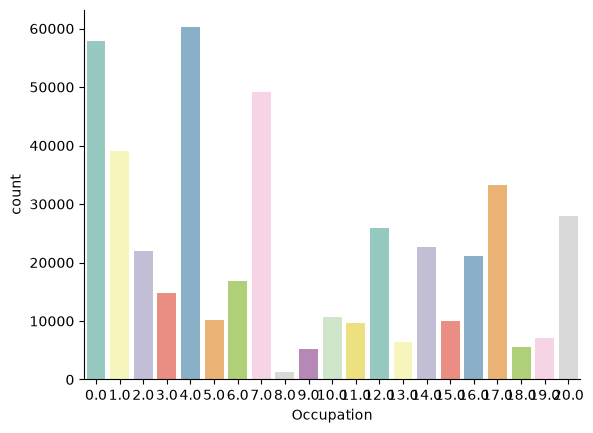

In [62]:
sns.countplot(x="Occupation", data=blackfriday, palette="Set3")
sns.despine()
#Podríamos cambiar los axis

In [63]:
blackfriday['Occupation'].value_counts()

Occupation
4.0     60180
0.0     57924
7.0     49151
1.0     39031
17.0    33285
20.0    27948
12.0    25958
14.0    22702
2.0     21927
16.0    21166
6.0     16884
3.0     14839
10.0    10734
5.0     10129
15.0     9984
11.0     9610
19.0     7061
13.0     6357
18.0     5541
9.0      5218
8.0      1311
Name: count, dtype: int64

In [64]:
imputer = SimpleImputer(missing_values=np.nan, strategy="most_frequent")

In [65]:
blackfriday_imputados = imputer.fit_transform(blackfriday[['Occupation']])

In [66]:
np.shape(blackfriday_imputados)

(537577, 1)

In [67]:
blackfriday_imputados[:10]

array([[10.],
       [ 4.],
       [10.],
       [10.],
       [16.],
       [15.],
       [ 7.],
       [ 7.],
       [ 4.],
       [20.]])

In [68]:
blackfriday["Occupation"] = blackfriday_imputados

In [69]:
blackfriday.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,14.0,10.0,A,2,0,3,NaN,NaN,8370.0
1,1000001,P00248942,F,15.0,4.0,A,2,0,1,6.0,14.0,15200.0
2,1000001,P00087842,NaN,15.0,10.0,A,2,0,12,NaN,NaN,1422.0
3,1000001,P00085442,F,15.0,10.0,A,2,0,12,14.0,NaN,1057.0
4,1000002,P00285442,M,60.0,16.0,C,4+,0,8,NaN,NaN,7969.0


In [70]:
blackfriday['Occupation'].value_counts()

Occupation
4.0     140817
0.0      57924
7.0      49151
1.0      39031
17.0     33285
20.0     27948
12.0     25958
14.0     22702
2.0      21927
16.0     21166
6.0      16884
3.0      14839
10.0     10734
5.0      10129
15.0      9984
11.0      9610
19.0      7061
13.0      6357
18.0      5541
9.0       5218
8.0       1311
Name: count, dtype: int64

**Variable: `Age`**

In [71]:
blackfriday['Age'].describe()

count    510698.000000
mean         34.321239
std          11.640546
min          14.000000
25%          26.000000
50%          32.000000
75%          42.000000
max          74.000000
Name: Age, dtype: float64

In [72]:
imputer_age = SimpleImputer(missing_values=np.nan, strategy="mean")

In [73]:
# Convertir la columna 'Age' de string a entero
# Ver el tipo de dato de una columna específica
print(blackfriday['Age'].dtype)

float64


In [74]:
blackfriday['Age'].describe()

count    510698.000000
mean         34.321239
std          11.640546
min          14.000000
25%          26.000000
50%          32.000000
75%          42.000000
max          74.000000
Name: Age, dtype: float64

**Variable: `Gender`**

In [75]:
blackfriday['Gender'].value_counts()

Gender
M    364872
F    118947
Name: count, dtype: int64

In [76]:
imputer_gen = SimpleImputer(missing_values=np.nan, strategy="most_frequent")

In [77]:
blackfriday['Gender'] = imputer_gen.fit_transform(blackfriday[['Gender']]).ravel()

In [78]:
blackfriday['Gender'].value_counts()

Gender
M    418630
F    118947
Name: count, dtype: int64

**Variable `Purchase`**

In [79]:
blackfriday.dropna(subset=['Purchase'], inplace=True)

**Columnas `Product_Category_2` and `Product_Category_3`**

In [80]:
blackfriday.drop(['Product_Category_2', 'Product_Category_3'], axis=1, inplace=True)

In [81]:
blackfriday.isna().sum()

User_ID                           0
Product_ID                        0
Gender                            0
Age                           26351
Occupation                        0
City_Category                     0
Stay_In_Current_City_Years        0
Marital_Status                    0
Product_Category_1                0
Purchase                          0
dtype: int64

#### DETECCION DE OUTLIERS

- Manera de detectar outliers:
    - z-score
        - Considera que todo valor que se aleje mucho de la media=0 es un outlier.
        - Depende de la media y el desvio estandard para medir la centralidad y dispersión, los cuales son muy afectados por outliers. Si las variables no tiene una distribución normal, termino removiendo muchos outliers del dataset.
        - No funciona bien en dataset muy pequeños.
    - Rango Intercuartil:
        - Es robusto y no es tan sensible a outliers.

In [82]:
blackfriday.dtypes

User_ID                         int64
Product_ID                        str
Gender                            str
Age                           float64
Occupation                    float64
City_Category                     str
Stay_In_Current_City_Years        str
Marital_Status                  int64
Product_Category_1              int64
Purchase                      float64
dtype: object

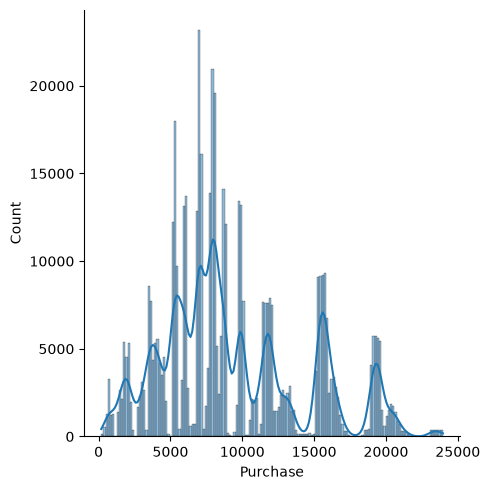

In [83]:
sns.displot(blackfriday['Purchase'], kde=True) #El gráfico muestra la frecuencia de los valores de compra, si hay sesgo, outliers o multiples grupos de compradores.
sns.despine() #kde=True muestra la curva de densidad

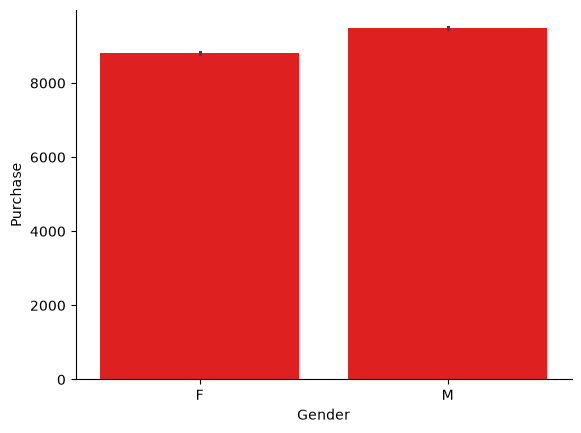

In [84]:
ax = sns.barplot(x='Gender', y='Purchase', data=blackfriday, color='#FF0000')
sns.despine() #despine es quitar los bordes, las espinas

In [85]:
z = stats.zscore(np.array(blackfriday['Purchase'])) #selecciona la columna compras, convierte esa columna en un array NumPy y calcula el Z-score

In [86]:
threshold = 2.0  #"Considero que un valor es un outlier si está a más de 2 desviaciones estándar de la media."

In [87]:
z_index = blackfriday['Purchase'][np.abs(z) < threshold].index

blackfriday_withzscore = blackfriday.loc[z_index]

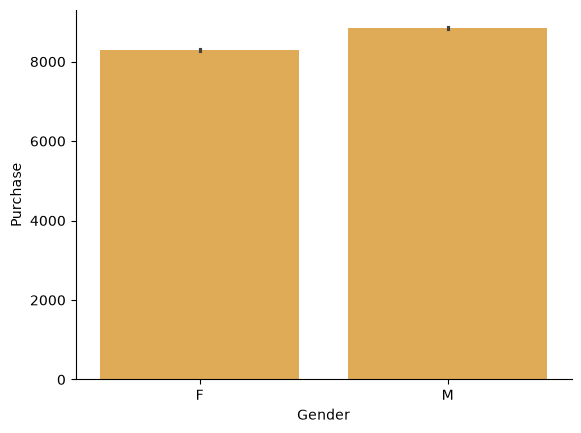

In [88]:
sns.barplot(x='Gender', y='Purchase', data=blackfriday_withzscore, color='#F5B041')
sns.despine()

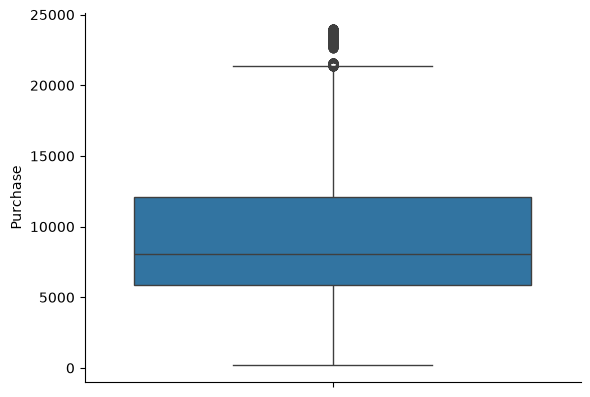

In [89]:
sns.boxplot(blackfriday['Purchase'])
sns.despine()

In [90]:
q1 = blackfriday['Purchase'].quantile(0.25)
q3 = blackfriday['Purchase'].quantile(0.75)

In [91]:
iqr = q3 - q1
lb = q1 - (iqr * 1.5)
ub = q3 + (iqr * 1.5)

In [92]:
bf = blackfriday[(blackfriday['Purchase'] > lb) & (blackfriday['Purchase'] < ub)]

In [93]:
bf.reset_index(drop=True, inplace=True)

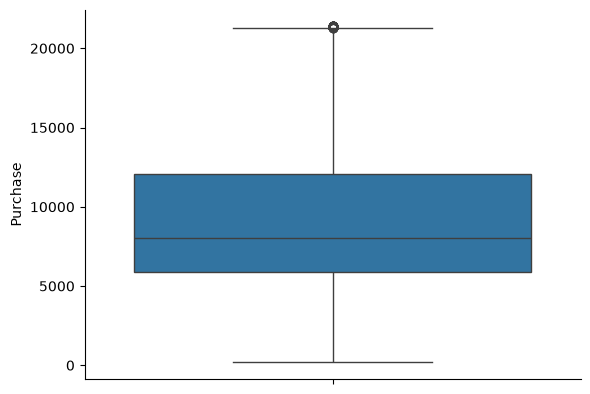

In [94]:
sns.boxplot(bf['Purchase'])
sns.despine()